<a href="https://colab.research.google.com/github/Linhlak/Machine-Learning-sem-5/blob/main/Practical_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 2


## Decision Tree Classifier

### 1. Load and Explore the Dataset

In [4]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/07_loan_approval.csv')

# Display basic information and the first few rows
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ApplicantID      600 non-null    object 
 1   Age              600 non-null    int64  
 2   AnnualIncome     600 non-null    int64  
 3   LoanAmount       600 non-null    int64  
 4   CreditScore      600 non-null    int64  
 5   EmploymentYears  600 non-null    float64
 6   Education        600 non-null    object 
 7   MaritalStatus    600 non-null    object 
 8   PropertyArea     600 non-null    object 
 9   SelfEmployed     600 non-null    object 
 10  LoanApproved     600 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 51.7+ KB
None


,ApplicantID,Age,AnnualIncome,LoanAmount,CreditScore,EmploymentYears,Education,MaritalStatus,PropertyArea,SelfEmployed,LoanApproved
0,L0001,25,35200,30000,703,7.4,Graduate,Married,Rural,No,Y
1,L0002,55,38300,133000,712,2.1,Graduate,Married,Urban,No,N
2,L0003,50,35800,95000,678,10.9,Graduate,Married,Semiurban,Yes,Y
3,L0004,40,43000,103000,694,5.2,Graduate,Married,Semiurban,No,N
4,L0005,40,77800,84000,728,3.4,Not Graduate,Divorced,Urban,No,N


### 2. Preprocess Data and Split into Train/Test Sets
We will encode categorical variables (converting Yes/No questions/answers into numerical values) and split the data into features ($X$) and target ($y$).

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

# Identify categorical columns to encode
categorical_cols = df.select_dtypes(include=['object']).columns

# Encode categorical variables
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Assuming 'loan_status' or similar is our target variable. Let's find the target column.
# If there is a clear target like 'loan_status', we use it, otherwise we default to the last column.
target_col = 'loan_status' if 'loan_status' in df.columns else df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col]

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (480, 10)
Testing set shape: (120, 10)


### 3. Train the Decision Tree Classifier and Visualize Decisions
A Decision Tree makes decisions based on a series of Yes/No (binary) questions.
* **Root Node**: The top-most decision point representing the entire dataset, split based on the most important feature.
* **Internal Nodes**: Decision points where a feature value is tested to branch the data further.
* **Branches**: The outcome paths of a decision (e.g., True/False, Yes/No).
* **Leaf Nodes**: The final prediction endpoints where no further splits are made.

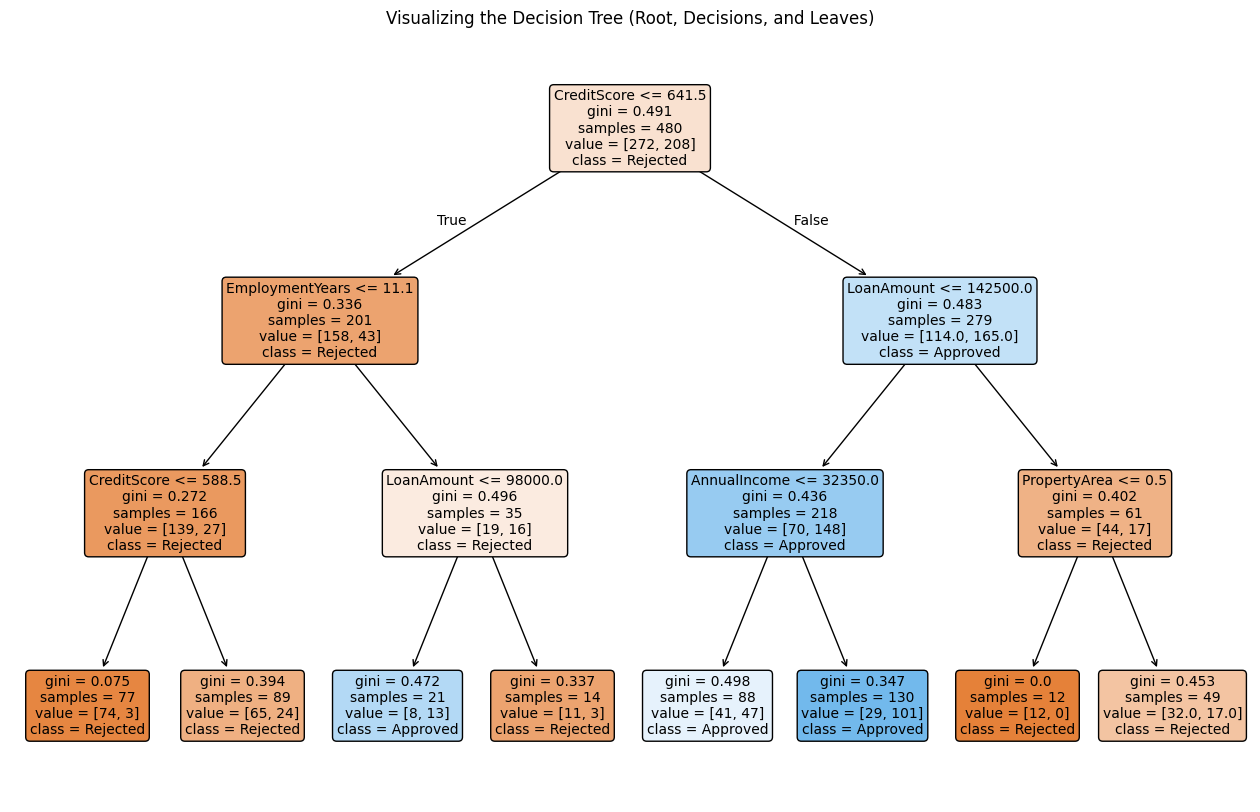

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Initialize and train the classifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42)  # Limited depth for clear visualization
clf.fit(X_train, y_train)

# Plot the tree structure
fig, ax = plt.subplots(figsize=(16, 10))
plot_tree(clf,
          feature_names=X.columns.tolist(),
          class_names=['Rejected', 'Approved'] if len(np.unique(y)) == 2 else [str(c) for c in clf.classes_],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)
plt.title("Visualizing the Decision Tree (Root, Decisions, and Leaves)")
plt.show()

### 4. Make Predictions and Evaluate

In [7]:
from sklearn.metrics import classification_report, accuracy_score

# Predict on the test set
y_pred = clf.predict(X_test)

# Print evaluation metrics
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 68.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.60      0.66        62
           1       0.64      0.78      0.70        58

    accuracy                           0.68       120
   macro avg       0.69      0.69      0.68       120
weighted avg       0.69      0.68      0.68       120



### Combined Decision Tree Program
Below is the complete, self-contained Python script implementing the entire workflow.

--- Step 1: Loading Dataset ---
Dataset loaded with shape: (600, 11)

--- Step 2: Preprocessing and Splitting ---
Training features shape: (480, 10)
Testing features shape: (120, 10)

--- Step 3: Training Decision Tree ---
Model trained successfully.

--- Step 4: Model Evaluation ---
Model Accuracy: 68.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.60      0.66        62
           1       0.64      0.78      0.70        58

    accuracy                           0.68       120
   macro avg       0.69      0.69      0.68       120
weighted avg       0.69      0.68      0.68       120

--- Step 5: Visualizing Tree Structure ---


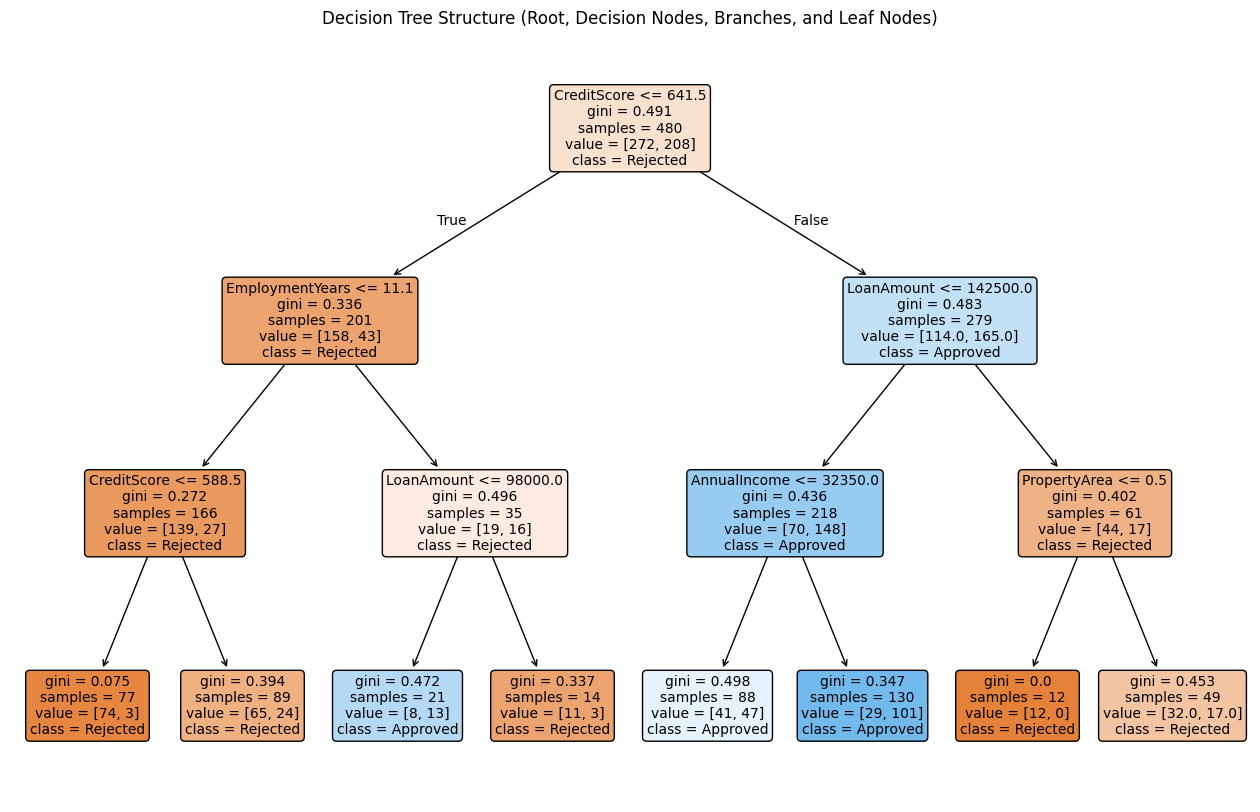

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

# ==========================================================
# 1. Load and Explore the Dataset
# ==========================================================
print("--- Step 1: Loading Dataset ---")
df = pd.read_csv('/content/07_loan_approval.csv')
df.columns = df.columns.str.strip()
print(f"Dataset loaded with shape: {df.shape}\n")

# ==========================================================
# 2. Preprocess Data and Split into Train/Test Sets
# ==========================================================
print("--- Step 2: Preprocessing and Splitting ---")
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

target_col = 'loan_status' if 'loan_status' in df.columns else df.columns[-1]
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}\n")

# ==========================================================
# 3. Train the Decision Tree Classifier
# ==========================================================
print("--- Step 3: Training Decision Tree ---")
# max_depth is set to 3 to keep the tree easily interpretable
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
print("Model trained successfully.\n")

# ==========================================================
# 4. Make Predictions and Evaluate
# ==========================================================
print("--- Step 4: Model Evaluation ---")
y_pred = clf.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ==========================================================
# 5. Visualize the Decision Tree Structure
# ==========================================================
print("--- Step 5: Visualizing Tree Structure ---")
fig, ax = plt.subplots(figsize=(16, 10))
plot_tree(clf,
          feature_names=X.columns.tolist(),
          class_names=['Rejected', 'Approved'] if len(np.unique(y)) == 2 else [str(c) for c in clf.classes_],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)
plt.title("Decision Tree Structure (Root, Decision Nodes, Branches, and Leaf Nodes)")
plt.show()

## Naive Bayes Classifiers (Bernoulli, Gaussian, and Multinomial)

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report

# ==========================================================
# 1. Load the Mushroom Edibility Dataset
# ==========================================================
print("--- Step 1: Loading Dataset ---")
mushroom_df = pd.read_csv('/11_mushroom_edibility.csv')
mushroom_df.columns = mushroom_df.columns.str.strip()
print(f"Mushroom dataset shape: {mushroom_df.shape}")
display(mushroom_df.head())

# ==========================================================
# 2. Preprocessing
# ==========================================================
print("\n--- Step 2: Preprocessing and Encoding ---")
# Convert categorical string labels into numerical values
label_encoders = {}
for col in mushroom_df.columns:
    le = LabelEncoder()
    mushroom_df[col] = le.fit_transform(mushroom_df[col].astype(str))
    label_encoders[col] = le

# Identify target column (assuming 'class' or similar represents edibility, e.g., edible/poisonous)
target_candidates = [col for col in mushroom_df.columns if 'class' in col.lower() or 'edib' in col.lower()]
target_col = target_candidates[0] if target_candidates else mushroom_df.columns[0]

X_nb = mushroom_df.drop(columns=[target_col])
y_nb = mushroom_df[target_col]

# Split into training and testing sets
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_nb, test_size=0.2, random_state=42
)
print(f"Features shape: {X_nb.shape}, Target column: '{target_col}'")

# ==========================================================
# 3. Gaussian Naive Bayes (Continuous/Normal Distribution assumption)
# ==========================================================
print("\n--- Step 3: Gaussian Naive Bayes ---")
gnb = GaussianNB()
gnb.fit(X_train_nb, y_train_nb)
y_pred_gnb = gnb.predict(X_test_nb)
print(f"Gaussian NB Accuracy: {accuracy_score(y_test_nb, y_pred_gnb):.2%}")

# ==========================================================
# 4. Multinomial Naive Bayes (Discrete count/frequency assumption)
# ==========================================================
print("\n--- Step 4: Multinomial Naive Bayes ---")
mnb = MultinomialNB()
mnb.fit(X_train_nb, y_train_nb)
y_pred_mnb = mnb.predict(X_test_nb)
print(f"Multinomial NB Accuracy: {accuracy_score(y_test_nb, y_pred_mnb):.2%}")

# ==========================================================
# 5. Bernoulli Naive Bayes (Binary/Boolean feature assumption)
# ==========================================================
print("\n--- Step 5: Bernoulli Naive Bayes ---")
bnb = BernoulliNB(binarize=0.5)  # Thresholding features to binarize them
bnb.fit(X_train_nb, y_train_nb)
y_pred_bnb = bnb.predict(X_test_nb)
print(f"Bernoulli NB Accuracy: {accuracy_score(y_test_nb, y_pred_bnb):.2%}")

# ==========================================================
# 6. Comparative Classification Reports
# ==========================================================
print("\n--- Step 6: Detailed Classification Report (Gaussian NB) ---")
print(classification_report(y_test_nb, y_pred_gnb))

--- Step 1: Loading Dataset ---
Mushroom dataset shape: (600, 11)


,SampleID,CapShape,CapColor,Odor,GillSpacing,GillColor,StalkShape,RingNumber,Habitat,Population,Class
0,S0001,flat,gray,foul,crowded,brown,tapering,one,woods,scattered,poisonous
1,S0002,convex,brown,almond,close,white,tapering,none,grasses,several,edible
2,S0003,convex,gray,none,distant,black,enlarging,two,leaves,scattered,poisonous
3,S0004,flat,yellow,none,close,white,enlarging,one,woods,abundant,poisonous
4,S0005,knobbed,gray,fishy,close,pink,enlarging,one,urban,several,poisonous



--- Step 2: Preprocessing and Encoding ---
Features shape: (600, 10), Target column: 'Class'

--- Step 3: Gaussian Naive Bayes ---
Gaussian NB Accuracy: 72.50%

--- Step 4: Multinomial Naive Bayes ---
Multinomial NB Accuracy: 66.67%

--- Step 5: Bernoulli Naive Bayes ---
Bernoulli NB Accuracy: 66.67%

--- Step 6: Detailed Classification Report (Gaussian NB) ---
              precision    recall  f1-score   support

           0       0.79      0.55      0.65        55
           1       0.70      0.88      0.78        65

    accuracy                           0.72       120
   macro avg       0.74      0.71      0.71       120
weighted avg       0.74      0.72      0.72       120



## K-Means Clustering on Mall Customers
We will use the `/Mall_Customers.csv` dataset to segment customers based on their annual income and spending score.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Load the dataset
df_mall = pd.read_csv('/Mall_Customers.csv')
display(df_mall.head())
print(df_mall.info())

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


### 2. Determine Optimal Clusters with the Elbow Method

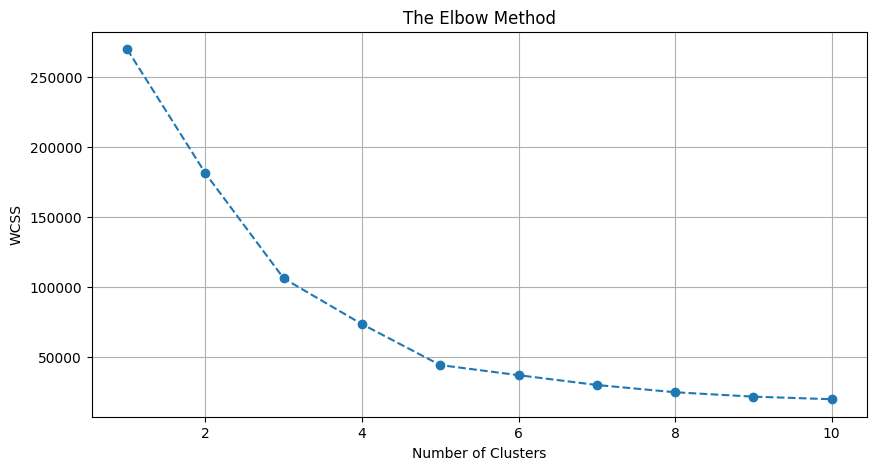

In [12]:
# We select 'Annual Income (k$)' and 'Spending Score (1-100)' for clustering
X_clusters = df_mall.iloc[:, [3, 4]].values

# Calculate Within-Cluster Sum of Square (WCSS) for different cluster counts
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_clusters)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

### 3. Apply K-Means Clustering and Visualize
Based on the Elbow plot, we can observe that the bend (elbow) is prominent at $k = 5$. We will group our customer data into 5 segments.

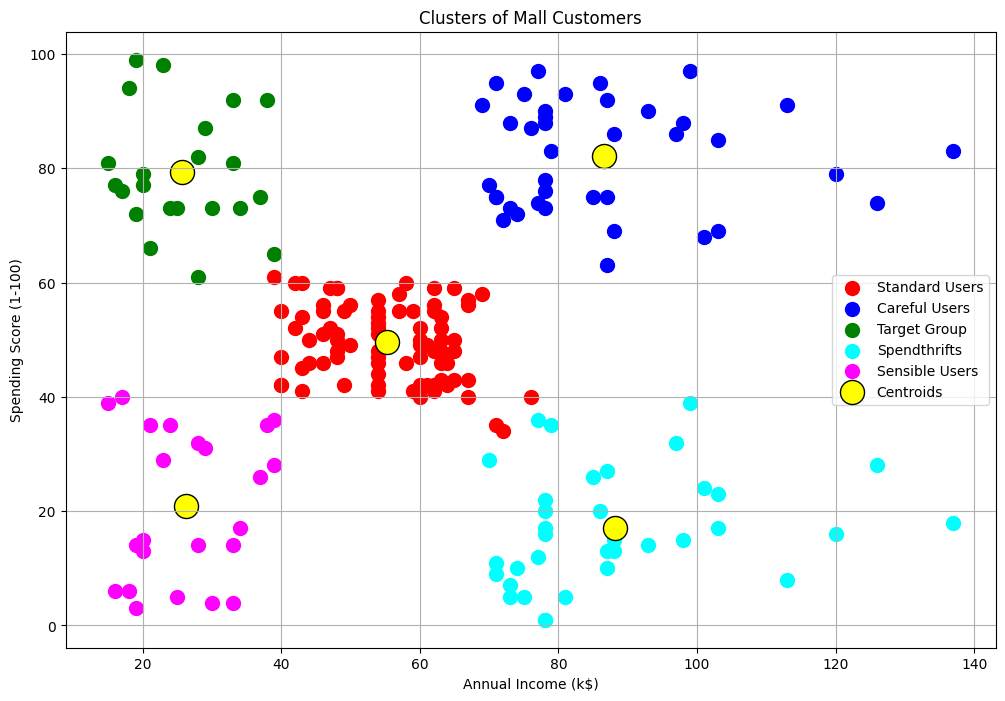

In [13]:
# Train K-Means model with optimal clusters
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_clusters)

# Visualize the clusters
plt.figure(figsize=(12, 8))
plt.scatter(X_clusters[y_kmeans == 0, 0], X_clusters[y_kmeans == 0, 1], s=100, c='red', label='Standard Users')
plt.scatter(X_clusters[y_kmeans == 1, 0], X_clusters[y_kmeans == 1, 1], s=100, c='blue', label='Careful Users')
plt.scatter(X_clusters[y_kmeans == 2, 0], X_clusters[y_kmeans == 2, 1], s=100, c='green', label='Target Group')
plt.scatter(X_clusters[y_kmeans == 3, 0], X_clusters[y_kmeans == 3, 1], s=100, c='cyan', label='Spendthrifts')
plt.scatter(X_clusters[y_kmeans == 4, 0], X_clusters[y_kmeans == 4, 1], s=100, c='magenta', label='Sensible Users')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids', edgecolor='black')
plt.title('Clusters of Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

### Combined K-Means Clustering Program
Below is the complete, self-contained Python program consolidating data loading, elbow method evaluation, and final visual clustering.

--- Step 1: Loading Dataset ---
Dataset loaded with shape: (200, 5)



,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



--- Step 2: Running Elbow Method ---
--- Step 3: Training K-Means Model (k=5) ---
Model clustering complete.



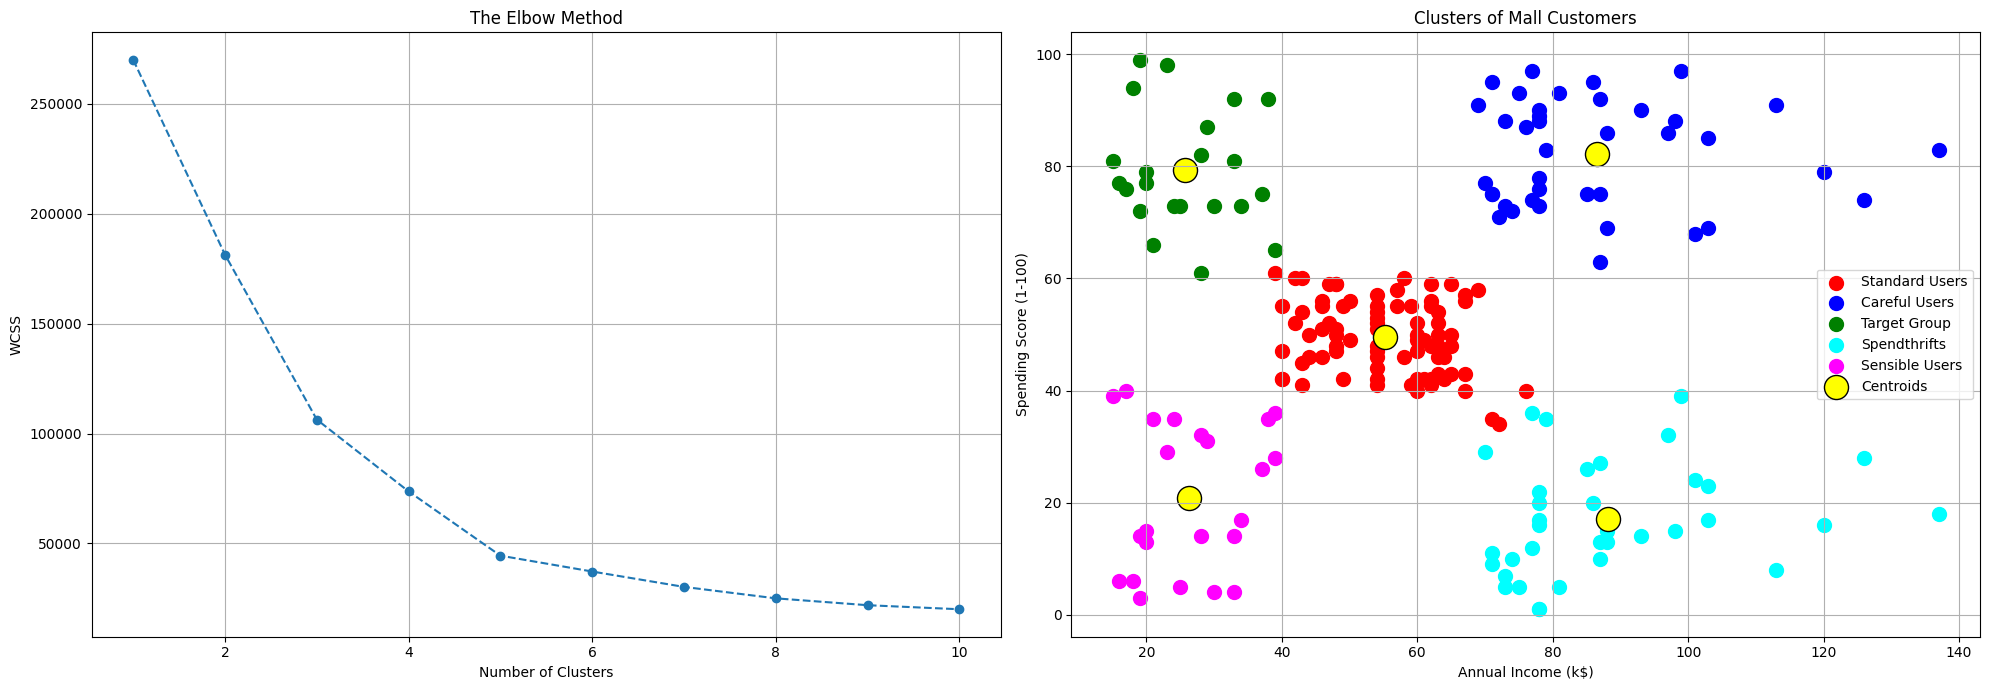

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ==========================================================
# 1. Load and Explore the Dataset
# ==========================================================
print("--- Step 1: Loading Dataset ---")
df_mall = pd.read_csv('/Mall_Customers.csv')
print(f"Dataset loaded with shape: {df_mall.shape}\n")
display(df_mall.head())

# ==========================================================
# 2. Extract Clustering Features
# ==========================================================
# Selecting 'Annual Income (k$)' and 'Spending Score (1-100)'
X_clusters = df_mall.iloc[:, [3, 4]].values

# ==========================================================
# 3. Determine Optimal Clusters with the Elbow Method
# ==========================================================
print("\n--- Step 2: Running Elbow Method ---")
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_clusters)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

ax1.plot(range(1, 11), wcss, marker='o', linestyle='--')
ax1.set_title('The Elbow Method')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('WCSS')
ax1.grid(True)

# ==========================================================
# 4. Train K-Means Model with Optimal Clusters (k=5)
# ==========================================================
print("--- Step 3: Training K-Means Model (k=5) ---")
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_clusters)
print("Model clustering complete.\n")

# ==========================================================
# 5. Visualize the Segmented Clusters
# ==========================================================
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Standard Users', 'Careful Users', 'Target Group', 'Spendthrifts', 'Sensible Users']

for cluster_idx in range(k_optimal):
    ax2.scatter(X_clusters[y_kmeans == cluster_idx, 0],
                X_clusters[y_kmeans == cluster_idx, 1],
                s=100,
                c=colors[cluster_idx],
                label=labels[cluster_idx])

# Plot cluster centroids
ax2.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300,
            c='yellow',
            label='Centroids',
            edgecolor='black')

ax2.set_title('Clusters of Mall Customers')
ax2.set_xlabel('Annual Income (k$)')
ax2.set_ylabel('Spending Score (1-100)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Support Vector Machine (SVM) Classification

Support Vector Machines (SVMs) are powerful supervised learning models used for classification and regression.
* **Hyperplane**: The decision boundary that separates different classes in the feature space.
* **Support Vectors**: The data points closest to the hyperplane that influence its position and orientation.
* **Margin**: The distance between the hyperplane and the nearest support vectors. SVM aims to maximize this margin to ensure generalizability.
* **Kernel Trick**: Allows SVMs to project low-dimensional non-linearly separable data into a higher-dimensional space where it becomes linearly separable (e.g., using Linear, RBF, or Polynomial kernels).

We will build a classification model to authenticate banknotes based on wavelet transform statistics from the selected `/data_banknote_authentication.txt` dataset.

--- Step 1: Loading Dataset ---
Dataset loaded with shape: (1372, 5)



,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0



--- Step 2: Preprocessing and Splitting ---
Features scaled (crucial for establishing optimal margins) and split complete.

--- Step 3: Training SVM Classifier (utilizing the RBF Kernel Trick) ---
Model trained successfully.

--- Step 4: Model Evaluation ---
Accuracy Score: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       127

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275


--- Step 5: Visualizing Decision Boundary, Support Vectors, and Margins ---


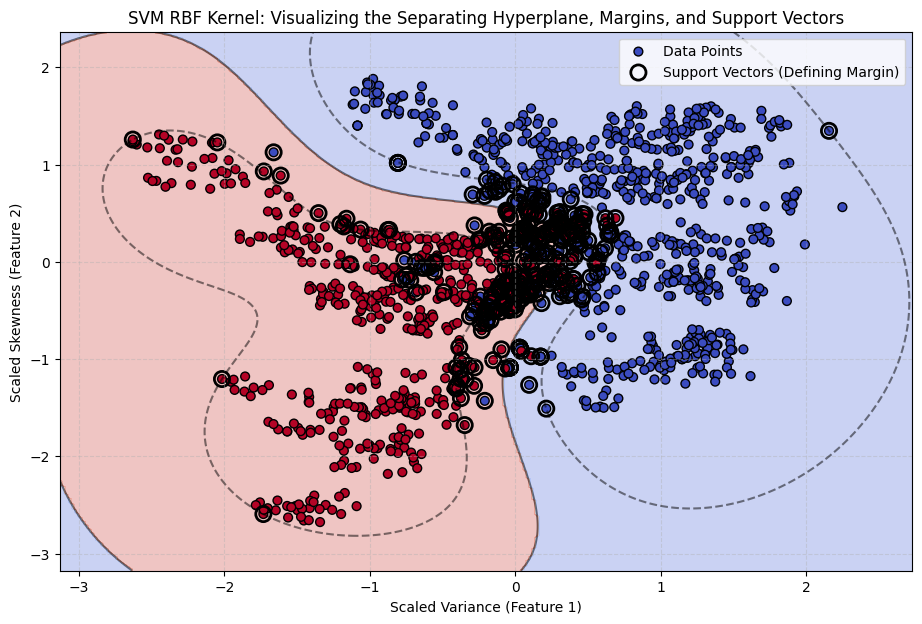

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

# ==========================================================
# 1. Load and Explore the Dataset
# ==========================================================
print("--- Step 1: Loading Dataset ---")
columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']
df_svm = pd.read_csv('/data_banknote_authentication.txt', header=None, names=columns)
print(f"Dataset loaded with shape: {df_svm.shape}\n")
display(df_svm.head())

# ==========================================================
# 2. Preprocess Data and Split into Train/Test Sets
# ==========================================================
print("\n--- Step 2: Preprocessing and Splitting ---")
X_svm = df_svm.drop(columns=['Class'])
y_svm = df_svm['Class']

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42
)

# Scaling is critical for maximizing the margin accurately
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_svm)
X_test_scaled = scaler.transform(X_test_svm)
print("Features scaled (crucial for establishing optimal margins) and split complete.")

# ==========================================================
# 3. Train Support Vector Classifier (using the Kernel Trick)
# ==========================================================
# CONCEPT - KERNEL TRICK: We use the RBF (Radial Basis Function) kernel here
# to project our non-linearly separable data into a higher-dimensional space
# where a clean separating decision boundary can be established.
print("\n--- Step 3: Training SVM Classifier (utilizing the RBF Kernel Trick) ---")
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train_svm)
print("Model trained successfully.")

# ==========================================================
# 4. Make Predictions and Evaluate
# ==========================================================
print("\n--- Step 4: Model Evaluation ---")
y_pred_svm = svm_model.predict(X_test_scaled)
print(f"Accuracy Score: {accuracy_score(y_test_svm, y_pred_svm):.2%}\n")
print("Classification Report:")
print(classification_report(y_test_svm, y_pred_svm))

# ==========================================================
# 5. Visualize Decision Boundary (Hyperplane, Support Vectors & Margin)
# ==========================================================
print("\n--- Step 5: Visualizing Decision Boundary, Support Vectors, and Margins ---")
# Train 2D SVM on the top two features for visual analysis
X_vis = X_svm[['Variance', 'Skewness']].values
y_vis = y_svm.values

scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

# Fit SVM to find the separating Hyperplane and Support Vectors in 2D
svm_vis = SVC(kernel='rbf', C=1.0, random_state=42)
svm_vis.fit(X_vis_scaled, y_vis)

# Create a mesh grid to plot the decision boundary
x_min, x_max = X_vis_scaled[:, 0].min() - 0.5, X_vis_scaled[:, 0].max() + 0.5
y_min, y_max = X_vis_scaled[:, 1].min() - 0.5, X_vis_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Decision function values are proportional to the distance from the separating Hyperplane
Z_boundary = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z_boundary = Z_boundary.reshape(xx.shape)

Z_distance = svm_vis.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z_distance = Z_distance.reshape(xx.shape)

plt.figure(figsize=(11, 7))

# Plot the non-linear Hyperplane decision regions mapping via Kernel Trick
plt.contourf(xx, yy, Z_boundary, alpha=0.3, cmap=plt.cm.coolwarm)

# CONCEPT - MARGIN: Plot the margin boundaries where the decision function is -1 or 1
plt.contour(xx, yy, Z_distance, colors='black', levels=[-1, 0, 1], alpha=0.5,
             linestyles=['--', '-', '--'])

# Plot all the data points
scatter = plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y_vis,
            edgecolors='k', cmap=plt.cm.coolwarm, s=40, label='Data Points')

# CONCEPT - SUPPORT VECTORS: Highlight support vectors that lie on or inside the margins
plt.scatter(svm_vis.support_vectors_[:, 0], svm_vis.support_vectors_[:, 1],
            s=120, facecolors='none', edgecolors='black', linewidths=2.0,
            label='Support Vectors (Defining Margin)')

# Add informational plot text
plt.title('SVM RBF Kernel: Visualizing the Separating Hyperplane, Margins, and Support Vectors')
plt.xlabel('Scaled Variance (Feature 1)')
plt.ylabel('Scaled Skewness (Feature 2)')
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()